In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
# Load dataset
df = pd.read_csv("myplacement.csv")

print(df.head())
print("\nDataset Shape:", df.shape)
print("\nDataset Information:")
print(df.info())

   CGPA  IQ  Placement
0  2.08  65          0
1  2.20  70          0
2  2.32  75          0
3  2.40  81          0
4  2.48  66          0

Dataset Shape: (30, 3)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   CGPA       30 non-null     float64
 1   IQ         30 non-null     int64  
 2   Placement  30 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 852.0 bytes
None


In [6]:
df

,CGPA,IQ,Placement
0,2.08,65,0
1,2.20,70,0
2,2.32,75,0
3,2.40,81,0
4,2.48,66,0
5,2.56,85,0
6,2.60,72,0
7,2.68,77,0
8,2.72,88,0
9,2.80,68,0


# Separate Features and Target

In [7]:
X = df[["CGPA", "IQ"]]
y = df["Placement"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   CGPA  IQ
0  2.08  65
1  2.20  70
2  2.32  75
3  2.40  81
4  2.48  66

Target:
0    0
1    0
2    0
3    0
4    0
Name: Placement, dtype: int64


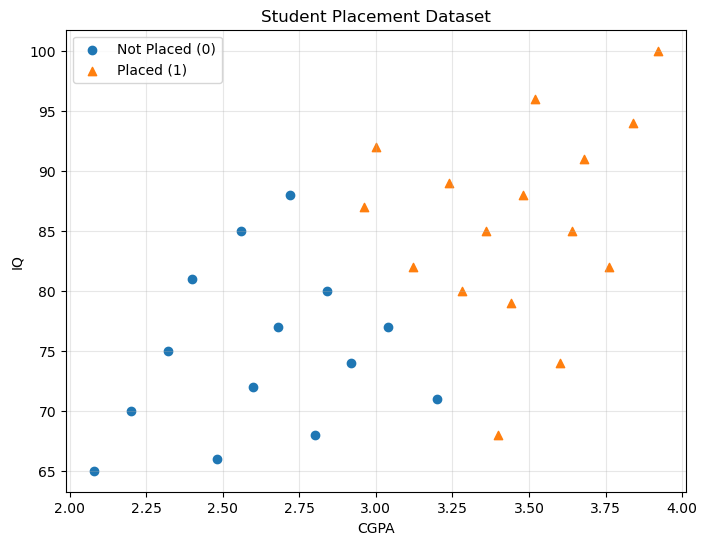

In [8]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df[df["Placement"] == 0]["CGPA"],
    df[df["Placement"] == 0]["IQ"],
    label="Not Placed (0)",
    marker="o"
)

plt.scatter(
    df[df["Placement"] == 1]["CGPA"],
    df[df["Placement"] == 1]["IQ"],
    label="Placed (1)",
    marker="^"
)

plt.xlabel("CGPA")
plt.ylabel("IQ")
plt.title("Student Placement Dataset")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 24
Testing samples: 6


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
perceptron_model = Perceptron(
    max_iter=1000,
    random_state=42
)

perceptron_model.fit(X_train_scaled, y_train)

y_pred_perceptron = perceptron_model.predict(X_test_scaled)



In [12]:
perceptron_accuracy = accuracy_score(
    y_test,
    y_pred_perceptron
)

perceptron_cm = confusion_matrix(
    y_test,
    y_pred_perceptron
)

print("Perceptron Accuracy:", perceptron_accuracy)
print("\nConfusion Matrix:")
print(perceptron_cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_perceptron, zero_division=0))

Perceptron Accuracy: 1.0

Confusion Matrix:
[[3 0]
 [0 3]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



In [13]:
def plot_decision_boundary(model, X, y, title):
    # Create meshgrid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Predict for every point in the grid
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid_points)
    Z = Z.reshape(xx.shape)

    # Plot decision regions
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")

    # Plot actual data points
    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        edgecolor="black",
        cmap="coolwarm"
    )

    plt.xlabel("Standardized CGPA")
    plt.ylabel("Standardized IQ")
    plt.title(title)
    plt.grid(alpha=0.2)
    plt.show()




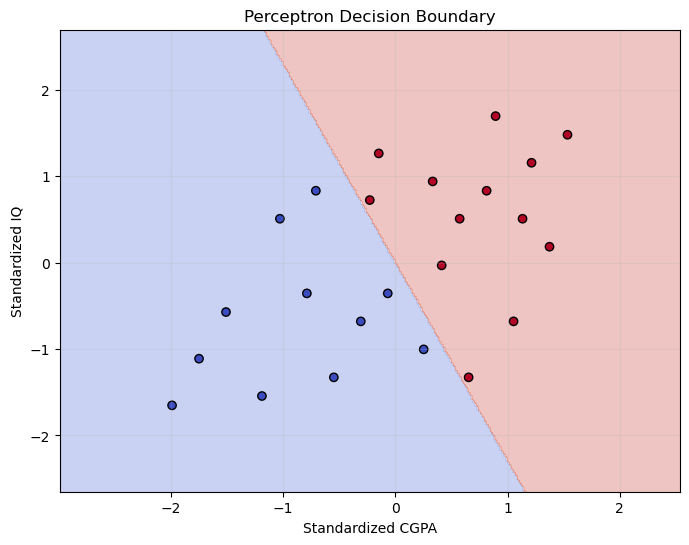

In [14]:
plot_decision_boundary(
    perceptron_model,
    X_train_scaled,
    y_train.to_numpy(),
    "Perceptron Decision Boundary"
)

In [15]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation="relu",
    solver="adam",
    max_iter=2000,
    random_state=42
)

mlp_model.fit(X_train_scaled, y_train)

y_pred_mlp = mlp_model.predict(X_test_scaled)

mlp_accuracy = accuracy_score(y_test, y_pred_mlp)

mlp_cm = confusion_matrix(y_test, y_pred_mlp)

print("MLP Accuracy:", mlp_accuracy)
print("\nConfusion Matrix:")
print(mlp_cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlp, zero_division=0))

MLP Accuracy: 1.0

Confusion Matrix:
[[3 0]
 [0 3]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



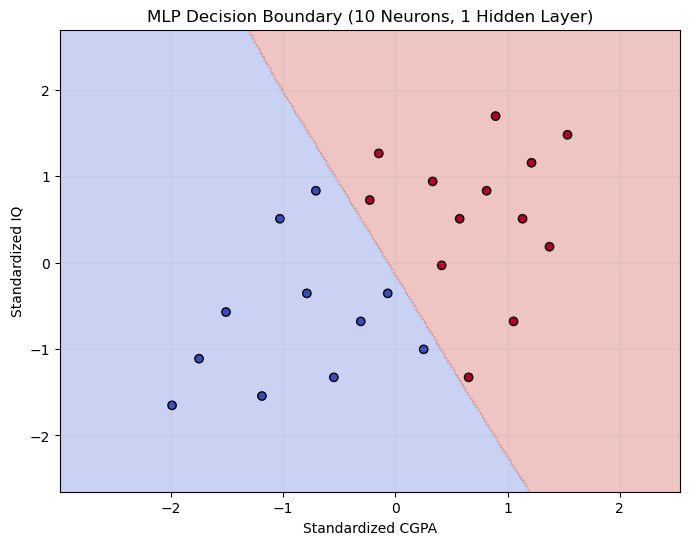

In [16]:
plot_decision_boundary(
    mlp_model,
    X_train_scaled,
    y_train.to_numpy(),
    "MLP Decision Boundary (10 Neurons, 1 Hidden Layer)"
)

In [17]:
architectures = {
    "1 Layer - 5 Neurons": (5,),
    "1 Layer - 10 Neurons": (10,),
    "1 Layer - 20 Neurons": (20,),
    "2 Layers - 10, 5 Neurons": (10, 5),
    "2 Layers - 20, 10 Neurons": (20, 10),
    "3 Layers - 20, 10, 5 Neurons": (20, 10, 5)
}

results = []

for name, layers in architectures.items():

    model = MLPClassifier(
        hidden_layer_sizes=layers,
        activation="relu",
        solver="adam",
        max_iter=2000,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, predictions)
    cm = confusion_matrix(y_test, predictions)

    results.append({
        "Architecture": name,
        "Accuracy": accuracy,
        "Confusion Matrix": cm
    })

    print("\nArchitecture:", name)
    print("Accuracy:", accuracy)
    print("Confusion Matrix:")
    print(cm)


Architecture: 1 Layer - 5 Neurons
Accuracy: 1.0
Confusion Matrix:
[[3 0]
 [0 3]]

Architecture: 1 Layer - 10 Neurons
Accuracy: 1.0
Confusion Matrix:
[[3 0]
 [0 3]]

Architecture: 1 Layer - 20 Neurons
Accuracy: 1.0
Confusion Matrix:
[[3 0]
 [0 3]]

Architecture: 2 Layers - 10, 5 Neurons
Accuracy: 1.0
Confusion Matrix:
[[3 0]
 [0 3]]

Architecture: 2 Layers - 20, 10 Neurons
Accuracy: 1.0
Confusion Matrix:
[[3 0]
 [0 3]]

Architecture: 3 Layers - 20, 10, 5 Neurons
Accuracy: 1.0
Confusion Matrix:
[[3 0]
 [0 3]]


In [18]:
results_df = pd.DataFrame([
    {
        "Architecture": result["Architecture"],
        "Accuracy": result["Accuracy"]
    }
    for result in results
])

print(results_df)

                   Architecture  Accuracy
0           1 Layer - 5 Neurons       1.0
1          1 Layer - 10 Neurons       1.0
2          1 Layer - 20 Neurons       1.0
3      2 Layers - 10, 5 Neurons       1.0
4     2 Layers - 20, 10 Neurons       1.0
5  3 Layers - 20, 10, 5 Neurons       1.0


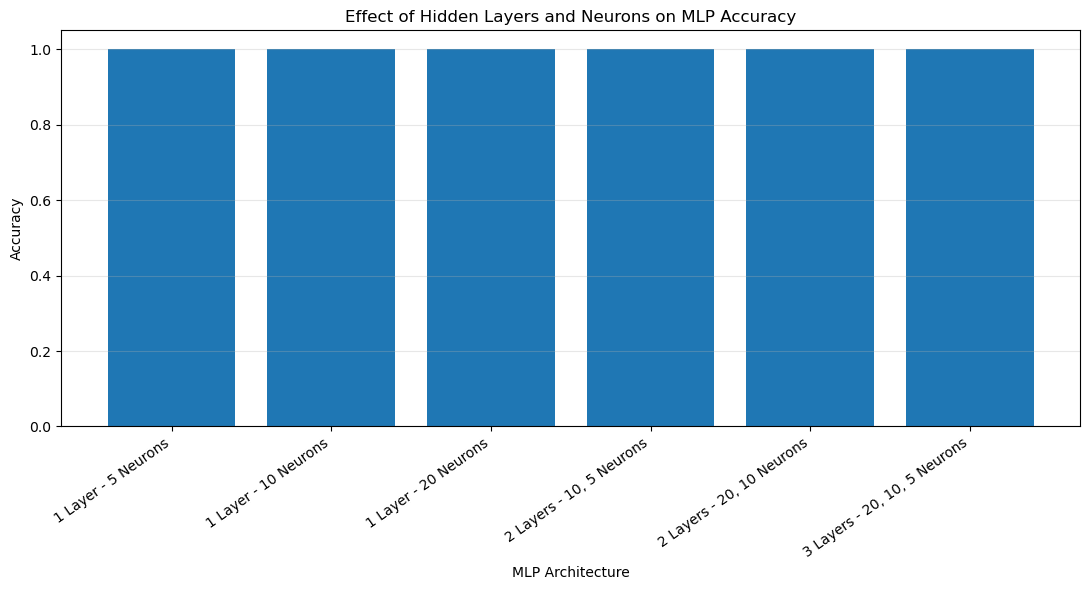

In [19]:
plt.figure(figsize=(11, 6))

plt.bar(
    results_df["Architecture"],
    results_df["Accuracy"]
)

plt.xlabel("MLP Architecture")
plt.ylabel("Accuracy")
plt.title("Effect of Hidden Layers and Neurons on MLP Accuracy")
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
comparison_df = pd.DataFrame({
    "Model": ["Perceptron", "MLP"],
    "Accuracy": [perceptron_accuracy, mlp_accuracy]
})

print(comparison_df)

        Model  Accuracy
0  Perceptron       1.0
1         MLP       1.0


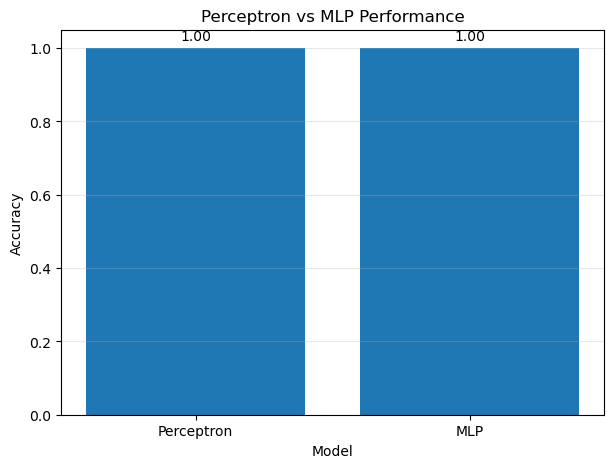

In [21]:
plt.figure(figsize=(7, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Perceptron vs MLP Performance")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)

for i, score in enumerate(comparison_df["Accuracy"]):
    plt.text(i, score + 0.02, f"{score:.2f}", ha="center")

plt.show()

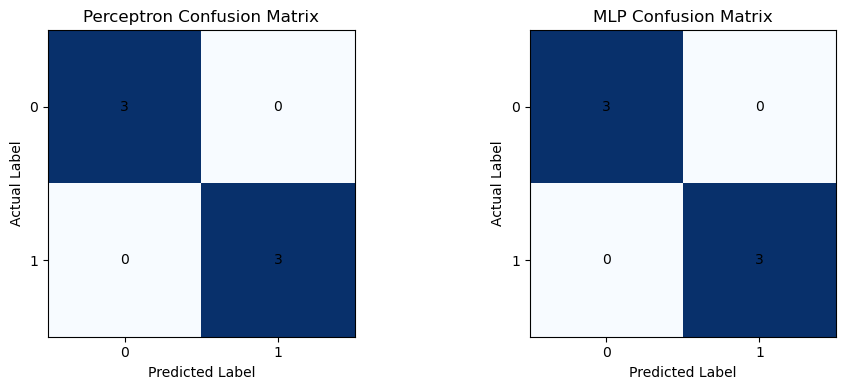

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

models = [
    ("Perceptron", perceptron_cm),
    ("MLP", mlp_cm)
]

for ax, (name, cm) in zip(axes, models):
    ax.imshow(cm, cmap="Blues")

    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()